In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

PROCESSED_PATH = '../data/processed/'

df_master = pd.read_parquet(PROCESSED_PATH + 'master_table.parquet')

print(f"master_table carregada: {df_master.shape}")
print(df_master.dtypes[['order_purchase_timestamp', 'pedido_atrasado', 'foi_entregue']])

master_table carregada: (99441, 34)
order_purchase_timestamp    datetime64[ns]
pedido_atrasado                       bool
foi_entregue                          bool
dtype: object


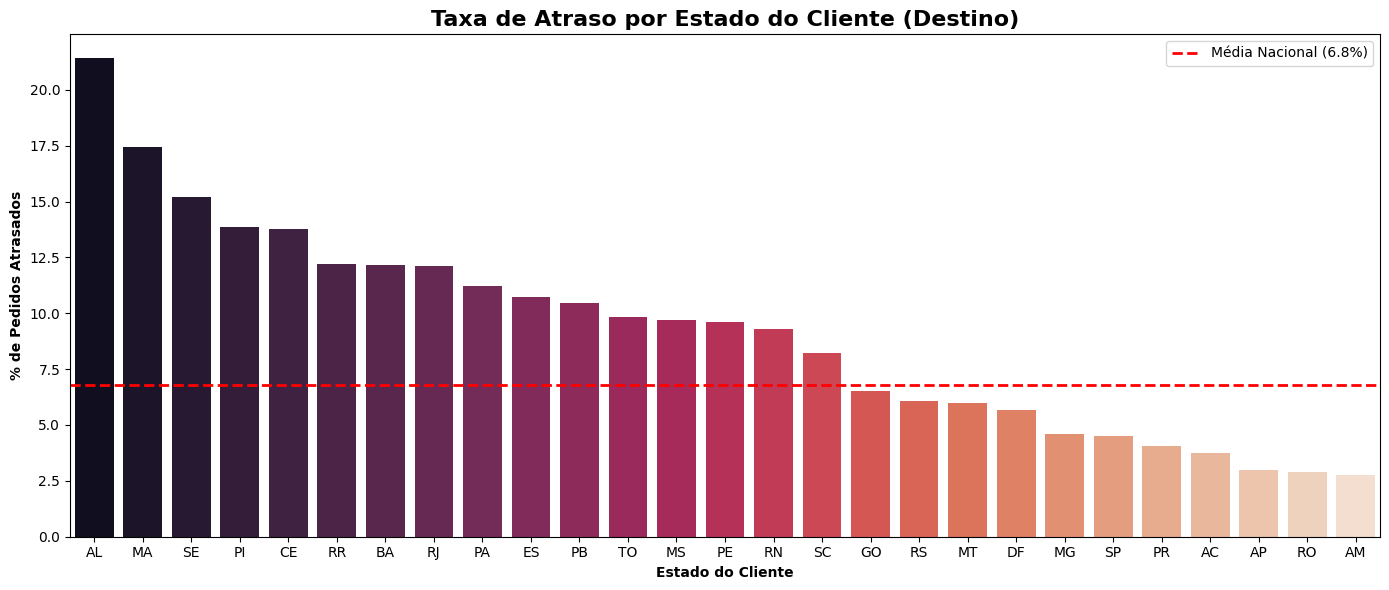

🔴 TOP 5 Estados com maiores taxas de atraso:
   customer_state  total_pedidos  taxa_atraso_pct
1              AL            397            21.41
9              MA            717            17.43
24             SE            335            15.22
16             PI            476            13.87
5              CE           1279            13.76


In [3]:
# ── PERGUNTA 1: Análise de Atrasos por Estado (Destino) ─────────────────────

# 1. Filtrando a base
# Quero analisar atrasos reais, então filtrei apenas pedidos que de fato foram entregues
entregues = df_master[df_master['foi_entregue'] == True].copy()

# 2. Agrupando e calculando a Taxa Relativa 
# Como a coluna 'pedido_atrasado' tem True (1) e False (0), a média dela nos dá exatamente a porcentagem!
atrasos_estado = entregues.groupby('customer_state').agg(
    total_pedidos=('order_id', 'count'),
    taxa_atraso=('pedido_atrasado', 'mean') 
).reset_index()

# Multiplicando por 100 para facilitar a leitura visual
atrasos_estado['taxa_atraso_pct'] = atrasos_estado['taxa_atraso'] * 100

# Ordenando do pior (maior taxa) para o melhor (menor taxa)
atrasos_estado = atrasos_estado.sort_values('taxa_atraso_pct', ascending=False)

# ── 3. Plotando o Gráfico de Barras ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

# Criando o gráfico de barras
# 
sns.barplot(
    data=atrasos_estado,
    x='customer_state',
    y='taxa_atraso_pct',
    palette='rocket', # Paleta que vai do vermelho escuro (pior) para o claro
    ax=ax
)

# Adicionando uma Linha de Base (Baseline) Crítica
media_nacional = entregues['pedido_atrasado'].mean() * 100
ax.axhline(media_nacional, color='red', linestyle='--', linewidth=2, 
           label=f'Média Nacional ({media_nacional:.1f}%)')

# Formatação e Estética
ax.set_title('Taxa de Atraso por Estado do Cliente (Destino)', fontsize=16, fontweight='bold')
ax.set_xlabel('Estado do Cliente', fontweight='bold')
ax.set_ylabel('% de Pedidos Atrasados', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

# Exibindo os números exatos do Top 5 piores
print("🔴 TOP 5 Estados com maiores taxas de atraso:")
print(atrasos_estado[['customer_state', 'total_pedidos', 'taxa_atraso_pct']].head(5).round(2))

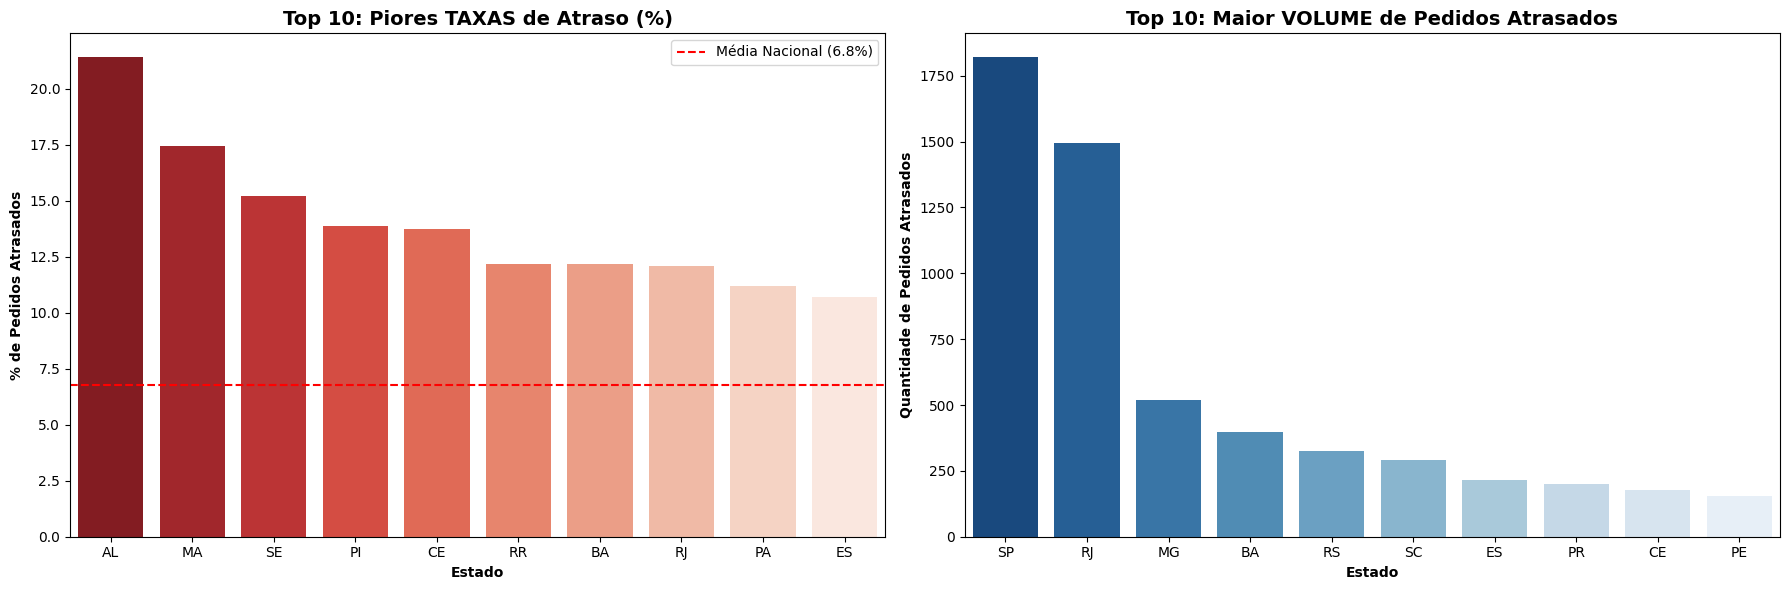

🚨 O Paradoxo de SP:
Taxa de atraso em SP: 4.5% (Abaixo da média nacional)
Volume de atrasos em SP: 1,820 pedidos (O maior ofensor do call center!)


In [4]:
# ── COMPLEMENTO PERGUNTA 1: Impacto Relativo (%) vs Impacto Absoluto (Volume) ──

# 1. Preparando os dados absolutos (apenas pedidos que atrasaram)
apenas_atrasados = entregues[entregues['pedido_atrasado'] == True]
volume_absoluto = apenas_atrasados.groupby('customer_state').agg(
    qtd_atrasos=('order_id', 'count')
).reset_index().sort_values('qtd_atrasos', ascending=False)

# Pegando apenas o TOP 10 de cada para o gráfico não ficar poluído
top10_taxa = atrasos_estado.head(10)
top10_volume = volume_absoluto.head(10)

# 2. Criando a figura com 2 gráficos lado a lado 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Gráfico 1: Impacto Relativo (Taxa %)
sns.barplot(data=top10_taxa, x='customer_state', y='taxa_atraso_pct', palette='Reds_r', ax=ax1)
ax1.axhline(media_nacional, color='red', linestyle='--', label=f'Média Nacional ({media_nacional:.1f}%)')
ax1.set_title('Top 10: Piores TAXAS de Atraso (%)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Estado', fontweight='bold')
ax1.set_ylabel('% de Pedidos Atrasados', fontweight='bold')
ax1.legend()

# Gráfico 2: Impacto Absoluto (Volume)
sns.barplot(data=top10_volume, x='customer_state', y='qtd_atrasos', palette='Blues_r', ax=ax2)
ax2.set_title('Top 10: Maior VOLUME de Pedidos Atrasados', fontsize=14, fontweight='bold')
ax2.set_xlabel('Estado', fontweight='bold')
ax2.set_ylabel('Quantidade de Pedidos Atrasados', fontweight='bold')

plt.tight_layout()
plt.show()

# ── EXIBINDO A COMPARAÇÃO DE SÃO PAULO ────────────────────────────────────────
sp_taxa = atrasos_estado[atrasos_estado['customer_state'] == 'SP']['taxa_atraso_pct'].values[0]
sp_vol = volume_absoluto[volume_absoluto['customer_state'] == 'SP']['qtd_atrasos'].values[0]

print(f"🚨 O Paradoxo de SP:")
print(f"Taxa de atraso em SP: {sp_taxa:.1f}% (Abaixo da média nacional)")
print(f"Volume de atrasos em SP: {sp_vol:,} pedidos (O maior ofensor do call center!)")

### 💡 Insight: O Paradoxo Logístico do Brasil (Taxa vs. Volume)

Existe um claro paradoxo entre a **taxa de atraso** e o **volume absoluto** de pedidos impactados:
- **Problema Estrutural (Nordeste):** Estados como AL (21,4%), MA (17,4%) e SE (15,2%) lideram as piores taxas, indicando forte deficiência na infraestrutura logística e malha rodoviária para essas regiões, operando com o dobro da média nacional de atrasos (6,6%).

- **Gargalo Operacional (Sudeste):** São Paulo (SP) possui uma taxa considerada "saudável" (4,5%), porém, devido ao seu volume colossal de compras, é o estado que gera o **maior número absoluto de atrasos** do país (mais de 1.800 pedidos).

**Ação de Negócio Sugerida:** Uma estratégia de mitigação precisa de duas frentes. Para o Nordeste, é necessário renegociar SLAs de prazo com transportadoras ou criar mini-hubs de distribuição (CDs). Para São Paulo, o foco deve ser eficiência de "last mile" (última milha) e automação de expedição, pois aqui é onde o call center mais "sangra".

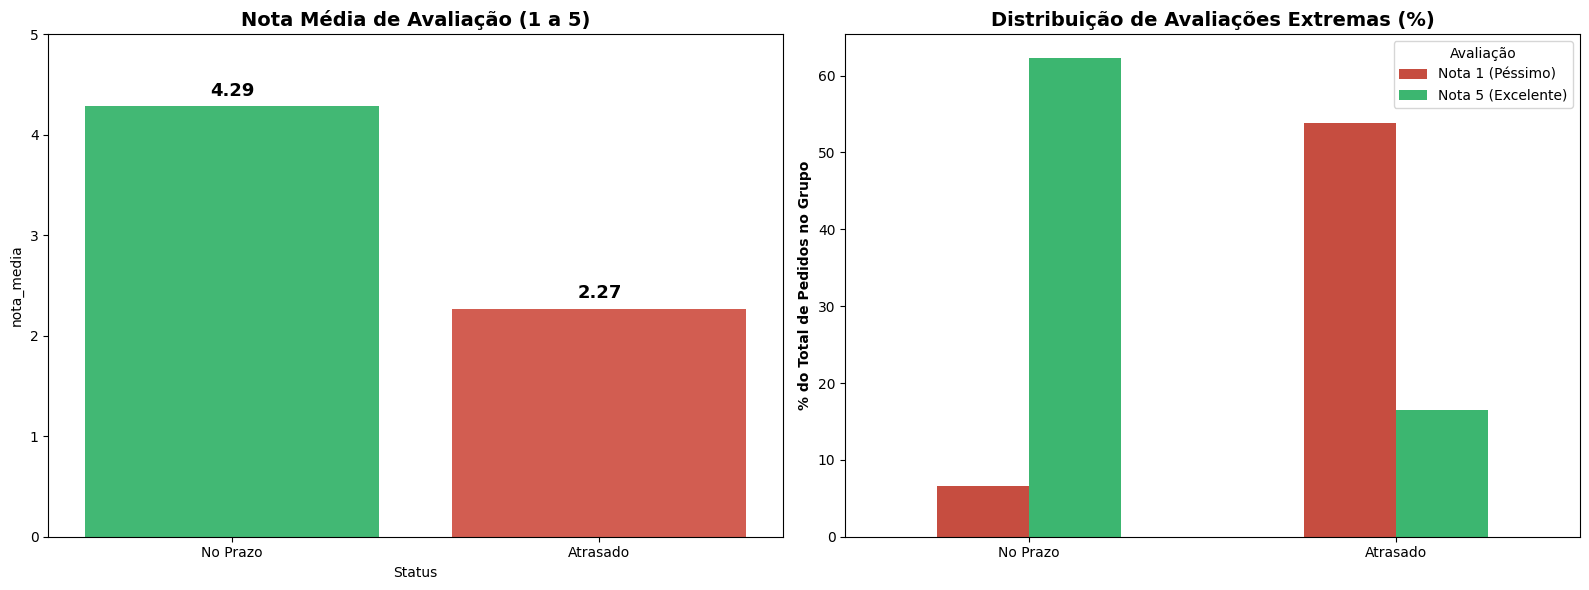

In [5]:
# ── PERGUNTA 2: Impacto dos atrasos na satisfação (Review Score) ────────────

# 1. Calculando a nota média geral por status de entrega
impacto_nota = entregues.groupby('pedido_atrasado').agg(
    nota_media=('review_score', 'mean'),
    volume=('order_id', 'count')
).reset_index()

# Trocando True/False por 'Atrasado' e 'No Prazo' para facilitar a leitura do gráfico
impacto_nota['Status'] = impacto_nota['pedido_atrasado'].map({False: 'No Prazo', True: 'Atrasado'})

# 2. Analisando a proporção de notas (1 a 5) por status
distribuicao_notas = pd.crosstab(
    entregues['pedido_atrasado'], 
    entregues['review_score'], 
    normalize='index' 
) * 100

distribuicao_notas.index = ['No Prazo', 'Atrasado']

# 3. Visualização Dupla: Nota Média vs Proporção de Extremos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Nota Média (Barplot)
sns.barplot(data=impacto_nota, x='Status', y='nota_media', palette=['#2ecc71', '#e74c3c'], ax=ax1)
ax1.set_title('Nota Média de Avaliação (1 a 5)', fontsize=14, fontweight='bold')
ax1.set_ylim(0, 5) # Força o eixo Y ir de 0 até 5 (nota máxima)

# Adicionando os números exatos em cima das barras
for i, v in enumerate(impacto_nota['nota_media']):
    ax1.text(i, v + 0.1, f"{v:.2f}", ha='center', fontsize=13, fontweight='bold')

# Gráfico 2: Proporção de Notas 1 (Péssimo) vs 5 (Excelente)
notas_extremos = distribuicao_notas[[1.0, 5.0]].copy()
notas_extremos.columns = ['Nota 1 (Péssimo)', 'Nota 5 (Excelente)']
notas_extremos.plot(kind='bar', ax=ax2, color=['#c0392b', '#27ae60'], alpha=0.9)

ax2.set_title('Distribuição de Avaliações Extremas (%)', fontsize=14, fontweight='bold')
ax2.set_ylabel('% do Total de Pedidos no Grupo', fontweight='bold')
ax2.tick_params(axis='x', rotation=0) # Deixa o texto 'No Prazo' e 'Atrasado' reto
ax2.legend(title='Avaliação')

plt.tight_layout()
plt.show()

In [6]:
# ── COMPLEMENTO PERGUNTA 2: Volume Absoluto de Notas 1 por Atraso ───────────

# Filtrando pedidos que atrasaram E receberam nota 1
detratores_atraso = entregues[(entregues['pedido_atrasado'] == True) & (entregues['review_score'] == 1.0)]
volume_detratores = len(detratores_atraso)

print(f"🚨 ALERTA DE REPUTAÇÃO:")
print(f"Total de pedidos atrasados que receberam Nota 1: {volume_detratores:,}")

🚨 ALERTA DE REPUTAÇÃO:
Total de pedidos atrasados que receberam Nota 1: 3,432


### 💡 Insight: A Destruição de Valor e Reputação (O Custo do Atraso)

O atraso na entrega é o principal ofensor da experiência do cliente. 
- **Queda de Satisfação:** Quando um pedido chega no prazo, a nota média é excelente (4.29). Quando atrasa, despenca para 2.27.

- **Inversão de Comportamento:** A entrega no prazo gera 62% de promotores (Nota 5). O atraso inverte completamente essa balança, gerando **54% de detratores extremos** (Nota 1).

- **Impacto Absoluto:** Foram geradas 3.432 avaliações Nota 1 puramente por quebra de SLA logístico. Esse volume massivo de insatisfação sobrecarrega o call center, afeta o NPS (Net Promoter Score) da plataforma e destrói a probabilidade de recompra (LTV - Lifetime Value).

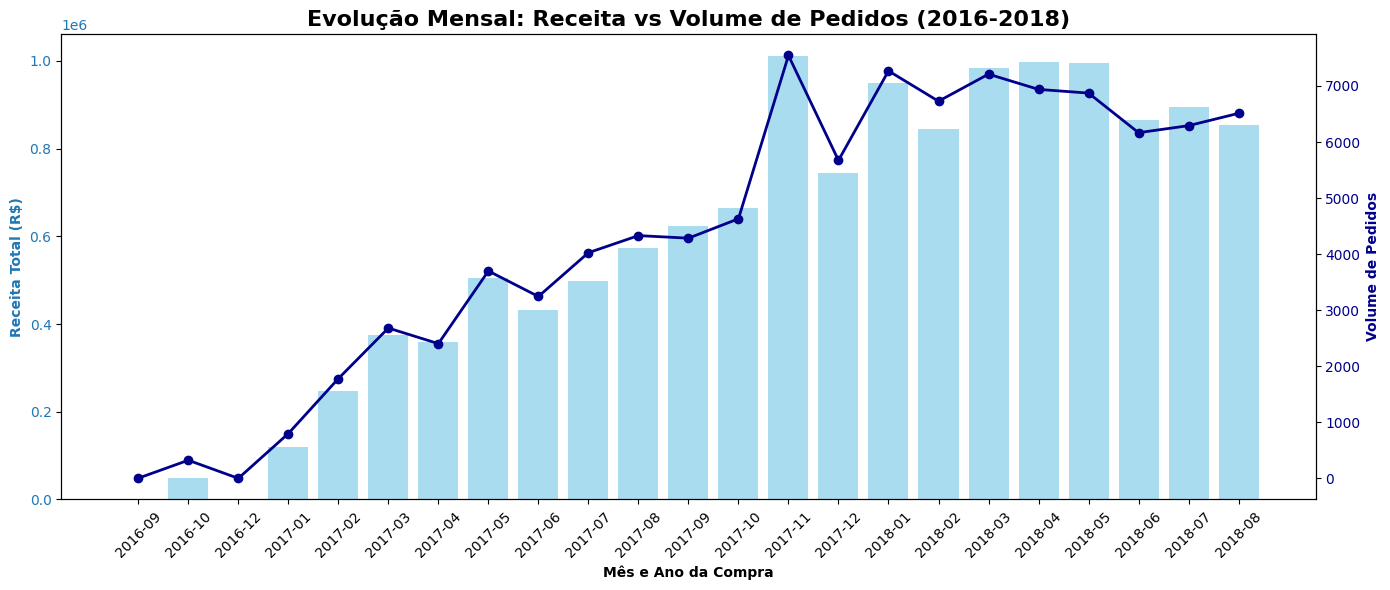

In [7]:
# ── PERGUNTA 3: Sazonalidade (Evolução de Receita e Volume) ─────────────────

# 1. Criando a coluna de Ano-Mês para a série temporal
df_master['ano_mes'] = df_master['order_purchase_timestamp'].dt.to_period('M').astype(str)

# 2. Agregando volume e receita por mês
evolucao_mensal = df_master.groupby('ano_mes').agg(
    volume_pedidos=('order_id', 'count'),          # Conta os pedidos únicos
    receita_total=('valor_total_produtos', 'sum')  # Soma o valor dos produtos
).reset_index()

# 3. FALSO DECLÍNIO (Corte de meses incompletos)
# Como o dataset termina em meados de setembro de 2018, esse mês possui poucos dias.
# Se mantido, criaria uma falsa ilusão de queda brusca nas vendas.
evolucao_mensal = evolucao_mensal[evolucao_mensal['ano_mes'] < '2018-09']

# 4. Plotando o Gráfico com Duplo Eixo Y
fig, ax1 = plt.subplots(figsize=(14, 6))

# Eixo da esquerda (Receita em Barras)
ax1.bar(
    evolucao_mensal['ano_mes'], 
    evolucao_mensal['receita_total'], 
    color='skyblue', 
    alpha=0.7, 
    label='Receita (R$)'
)
ax1.set_xlabel('Mês e Ano da Compra', fontweight='bold')
ax1.set_ylabel('Receita Total (R$)', color='tab:blue', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.tick_params(axis='x', rotation=45) # Inclina as datas em 45º para não sobrepor textos

# Eixo da direita (Volume em Linha)
ax2 = ax1.twinx()
ax2.plot(
    evolucao_mensal['ano_mes'], 
    evolucao_mensal['volume_pedidos'], 
    color='darkblue', 
    marker='o', 
    linewidth=2, 
    label='Volume de Pedidos'
)
ax2.set_ylabel('Volume de Pedidos', color='darkblue', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='darkblue')

# Configurações de Título e Layout
plt.title('Evolução Mensal: Receita vs Volume de Pedidos (2016-2018)', fontsize=16, fontweight='bold')
fig.tight_layout()
plt.show()

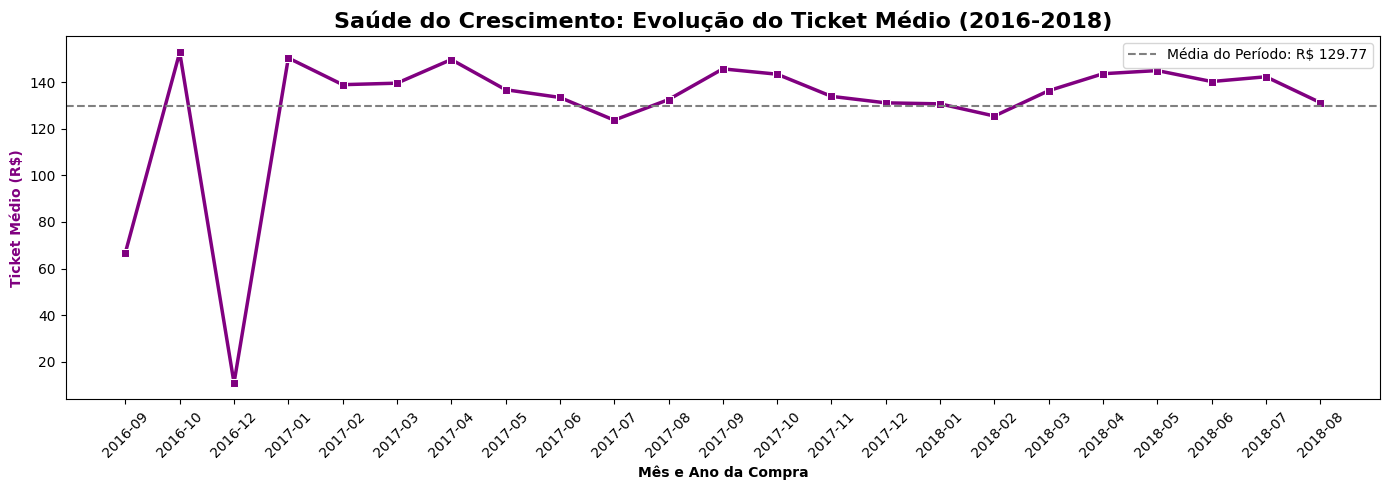

📊 DIAGNÓSTICO DE ESCALA:
Ticket Médio no Início (2016-09): R$ 66.84
Ticket Médio no Final (2018-08): R$ 131.25


In [8]:
# ── COMPLEMENTO PERGUNTA 3: Evolução do Ticket Médio Mensal ─────────────────

# 1. Calculando o Ticket Médio
# Ticket Médio = Receita Total / Volume de Pedidos
evolucao_mensal['ticket_medio'] = evolucao_mensal['receita_total'] / evolucao_mensal['volume_pedidos']

# 2. Plotando o Gráfico de Linha do Ticket Médio
fig, ax = plt.subplots(figsize=(14, 5))

# Criando o gráfico
sns.lineplot(
    data=evolucao_mensal, 
    x='ano_mes', 
    y='ticket_medio', 
    color='purple', 
    marker='s', # Marcadores quadrados para diferenciar da linha de volume
    linewidth=2.5,
    ax=ax
)

# Adicionando uma Linha de Base (Média Geral) para referência
media_geral_ticket = evolucao_mensal['ticket_medio'].mean()
ax.axhline(
    media_geral_ticket, 
    color='gray', 
    linestyle='--', 
    linewidth=1.5,
    label=f'Média do Período: R$ {media_geral_ticket:.2f}'
)

# Formatação e Estética
ax.set_title('Saúde do Crescimento: Evolução do Ticket Médio (2016-2018)', fontsize=16, fontweight='bold')
ax.set_xlabel('Mês e Ano da Compra', fontweight='bold')
ax.set_ylabel('Ticket Médio (R$)', color='purple', fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.legend()

plt.tight_layout()
plt.show()

# ── 3. Extraindo os números para o insight ──────────────────────────────
primeiro_mes = evolucao_mensal.iloc[0]['ano_mes']
ticket_primeiro = evolucao_mensal.iloc[0]['ticket_medio']

ultimo_mes = evolucao_mensal.iloc[-1]['ano_mes']
ticket_ultimo = evolucao_mensal.iloc[-1]['ticket_medio']

print(f"📊 DIAGNÓSTICO DE ESCALA:")
print(f"Ticket Médio no Início ({primeiro_mes}): R$ {ticket_primeiro:.2f}")
print(f"Ticket Médio no Final ({ultimo_mes}): R$ {ticket_ultimo:.2f}")

In [9]:
# Verificando os primeiros meses para checar se o volume é irrelevante
print("📦 Volume de pedidos nos primeiros meses do projeto:")
print(evolucao_mensal[['ano_mes', 'volume_pedidos', 'ticket_medio']].head(5))

📦 Volume de pedidos nos primeiros meses do projeto:
   ano_mes  volume_pedidos  ticket_medio
0  2016-09               4     66.840000
1  2016-10             324    152.801420
2  2016-12               1     10.900000
3  2017-01             800    150.391087
4  2017-02            1780    138.934281


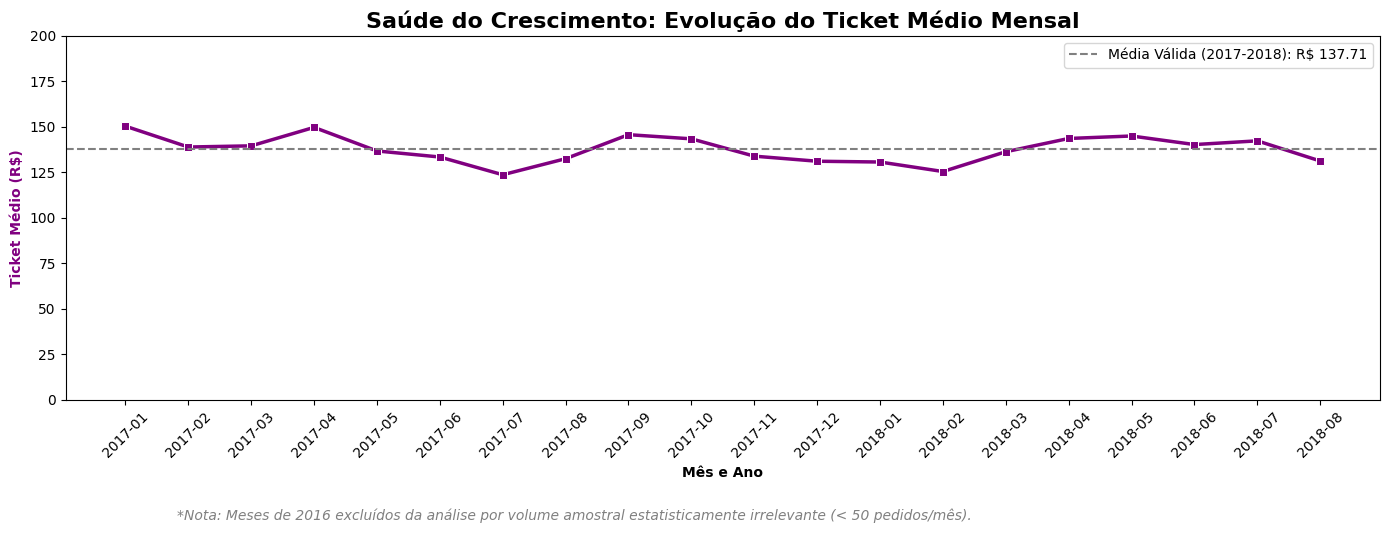

In [10]:
# ── REVISÃO PERGUNTA 3: Sazonalidade e Ticket Médio (Filtrado) ─────────────

# Aplicando a decisão analítica: filtrando dados a partir de Janeiro de 2017
evolucao_valida = evolucao_mensal[evolucao_mensal['ano_mes'] >= '2017-01'].copy()

# Recriando o gráfico de linha do Ticket Médio com a base corrigida
fig, ax = plt.subplots(figsize=(14, 5))

sns.lineplot(
    data=evolucao_valida, 
    x='ano_mes', 
    y='ticket_medio', 
    color='purple', 
    marker='s', 
    linewidth=2.5,
    ax=ax
)

# Adicionando a média do período válido
media_corrigida = evolucao_valida['ticket_medio'].mean()
ax.axhline(
    media_corrigida, 
    color='gray', 
    linestyle='--', 
    linewidth=1.5,
    label=f'Média Válida (2017-2018): R$ {media_corrigida:.2f}'
)

ax.set_title('Saúde do Crescimento: Evolução do Ticket Médio Mensal', fontsize=16, fontweight='bold')
ax.set_xlabel('Mês e Ano', fontweight='bold')
ax.set_ylabel('Ticket Médio (R$)', color='purple', fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.set_ylim(0, 200) # Mantém a escala Y visualmente confortável
ax.legend()

# Nota de rodapé formalizando a decisão diretamento no gráfico
plt.figtext(0.13, -0.05, "*Nota: Meses de 2016 excluídos da análise por volume amostral estatisticamente irrelevante (< 50 pedidos/mês).", 
            fontsize=10, color='gray', style='italic')

plt.tight_layout()
plt.show()

### 💡 Insight: Sazonalidade e Saúde do Crescimento

**Decisão Analítica Documentada:** Os dados referentes ao ano de 2016 (setembro, outubro e dezembro) foram excluídos da série temporal por apresentarem um volume amostral estatisticamente irrelevante (menos de 50 pedidos por mês, com alguns meses registrando apenas 1 pedido). A análise operacional válida se inicia em **Janeiro de 2017**. Esta decisão evita que ruídos da fase piloto corrompam a leitura das tendências.

**Conclusão Estratégica:**
A análise histórica válida revela que o hipercrescimento da plataforma foi extremamente saudável e sustentável. A Olist escalou seu volume de forma consistente — saindo de **800 pedidos em janeiro/2017 para um pico de ~7.500 pedidos em novembro/2017** — enquanto o **Ticket Médio se manteve sólido e perfeitamente estável, flutuando em torno de R$ 130,00 a R$ 140,00**. 

Isso confirma que o ganho de *market share* (fatia de mercado) e o aumento de volume não foram "comprados" de forma artificial através de descontos predatórios, o que fatalmente esmagaria as margens operacionais no longo prazo.

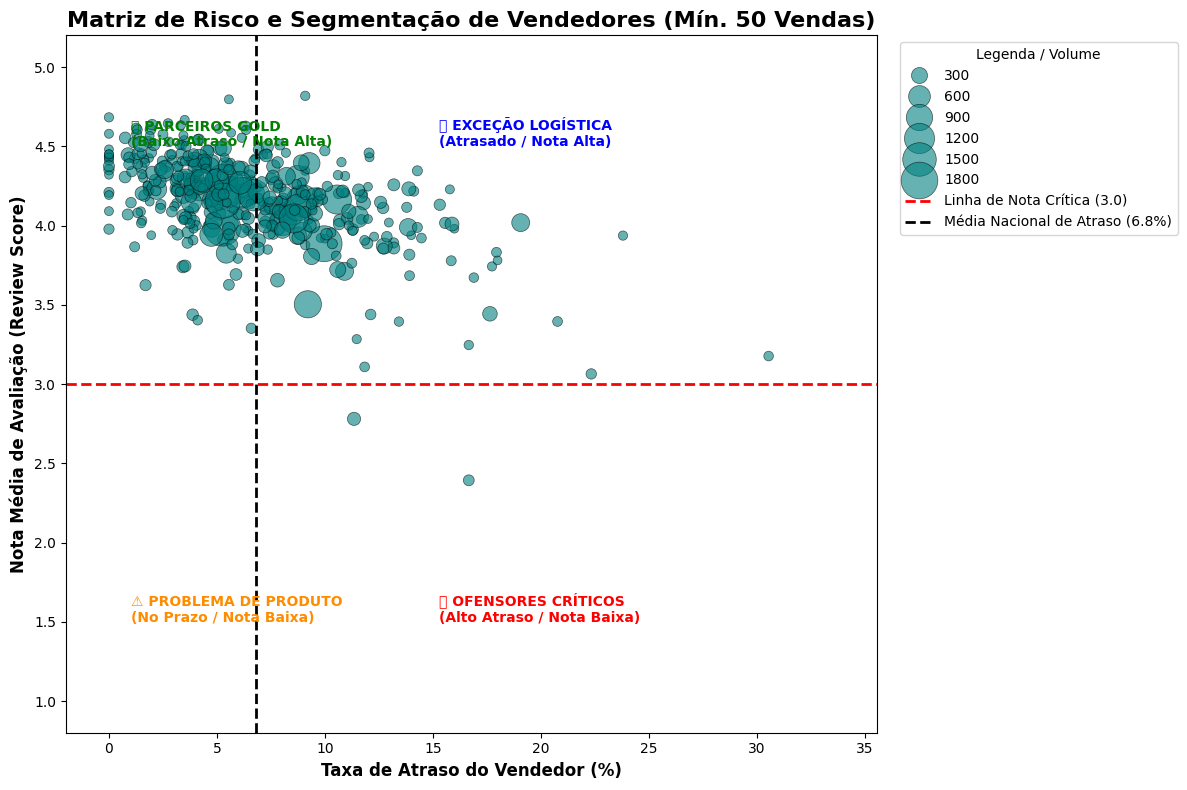

In [12]:
# ── MELHORIA PERGUNTA 4: Matriz de Segmentação Estratégica de Vendedores ──

fig, ax = plt.subplots(figsize=(12, 8))

# Criando o Scatter Plot (Gráfico de Dispersão)
# O tamanho (size) dos pontos representa o volume de vendas
sns.scatterplot(
    data=sellers_profissionais,
    x='taxa_atraso_pct',
    y='nota_media',
    size='volume_vendas',
    sizes=(40, 700), # Ajusta o tamanho mínimo e máximo das bolhas para dar contraste
    alpha=0.6,
    color='teal',
    edgecolor='black',
    ax=ax
)

# 1. Adicionando as linhas de referência que criam os 4 Quadrantes
ax.axhline(3.0, color='red', linestyle='--', linewidth=2, label='Linha de Nota Crítica (3.0)')
ax.axvline(6.8, color='black', linestyle='--', linewidth=2, label='Média Nacional de Atraso (6.8%)')

# Ajustando os limites dos eixos para a visualização não ficar espremida
max_atraso = sellers_profissionais['taxa_atraso_pct'].max()
ax.set_xlim(-2, max_atraso + 5)
ax.set_ylim(0.8, 5.2)

# 2. Rótulos Visuais para os Quadrantes (Análise Estratégica)
# Quadrante Superior Esquerdo: Baixo Atraso e Nota Alta
ax.text(1, 4.5, "✨ PARCEIROS GOLD\n(Baixo Atraso / Nota Alta)", fontsize=10, color='green', fontweight='bold')
# Quadrante Inferior Esquerdo: Baixo Atraso mas Nota Baixa
ax.text(1, 1.5, "⚠️ PROBLEMA DE PRODUTO\n(No Prazo / Nota Baixa)", fontsize=10, color='darkorange', fontweight='bold')
# Quadrante Superior Direito: Alto Atraso mas Nota Alta
ax.text(max_atraso/2, 4.5, "🚚 EXCEÇÃO LOGÍSTICA\n(Atrasado / Nota Alta)", fontsize=10, color='blue', fontweight='bold')
# Quadrante Inferior Direito: Alto Atraso e Nota Baixa
ax.text(max_atraso/2, 1.5, "🚨 OFENSORES CRÍTICOS\n(Alto Atraso / Nota Baixa)", fontsize=10, color='red', fontweight='bold')

# Formatação e Estética Executiva
ax.set_title('Matriz de Risco e Segmentação de Vendedores (Mín. 50 Vendas)', fontsize=16, fontweight='bold')
ax.set_xlabel('Taxa de Atraso do Vendedor (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Nota Média de Avaliação (Review Score)', fontsize=12, fontweight='bold')

# Move a legenda para fora do gráfico para não cobrir as bolhas
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), title="Legenda / Volume")

plt.tight_layout()
plt.show()

In [13]:
# ── TABELA-RESUMO: Quantificação dos Quadrantes Estratégicos ────────────────

# 1. Função para classificar cada vendedor no seu respectivo quadrante
def definir_quadrante(row):
    # Limites definidos na análise
    limite_atraso = 6.8
    limite_nota = 3.0
    
    if row['taxa_atraso_pct'] <= limite_atraso and row['nota_media'] >= limite_nota:
        return 'Parceiros Gold'
    elif row['taxa_atraso_pct'] <= limite_atraso and row['nota_media'] < limite_nota:
        return 'Problema de Produto'
    elif row['taxa_atraso_pct'] > limite_atraso and row['nota_media'] >= limite_nota:
        return 'Exceção Logística'
    else:
        return 'Ofensores Críticos'

# Aplicando a função linha a linha
sellers_profissionais['quadrante'] = sellers_profissionais.apply(definir_quadrante, axis=1)

# 2. Agrupando e calculando volume total e volume médio
resumo_quadrantes = sellers_profissionais.groupby('quadrante').agg(
    qtd_vendedores=('seller_id_principal', 'count'),
    volume_medio_vendas=('volume_vendas', 'mean')
).reset_index()

# Arredondando o volume médio para números inteiros (não existe "meia venda")
resumo_quadrantes['volume_medio_vendas'] = resumo_quadrantes['volume_medio_vendas'].astype(int)

# Ordenando pela quantidade de vendedores
resumo_quadrantes = resumo_quadrantes.sort_values('qtd_vendedores', ascending=False)

print("📊 TABELA ACIONÁVEL DE QUADRANTES:")
print(resumo_quadrantes.to_string(index=False))

📊 TABELA ACIONÁVEL DE QUADRANTES:
         quadrante  qtd_vendedores  volume_medio_vendas
    Parceiros Gold             250                  164
 Exceção Logística             167                  187
Ofensores Críticos               2                  146


### 💡 Insight: Segmentação Acionável de Vendedores (Matriz de Risco)

Para tornar a análise gráfica acionável, segmentamos os vendedores profissionais (com mais de 50 vendas) em 4 quadrantes operacionais, utilizando a média nacional de atraso (6,8%) e o limite de insatisfação (Nota 3,0) como réguas de corte:

| Quadrante | Perfil do Vendedor | Qtd. Vendedores | Volume Médio | Ação Sugerida |
| :--- | :--- | :--- | :--- | :--- |
| **Parceiros Gold** | Entregam no prazo e encantam o cliente. | **250** | **164** | Aumentar exposição no algoritmo e conceder bônus de comissão. |
| **Exceção Logística** | Atrasam além da média, mas mantêm nota alta. | **167** | **187** | Auditar transportadoras utilizadas e renegociar rotas específicas. |
| **Problema de Produto** | Entregam rápido, mas recebem avaliações péssimas. | **0** | **0** | *Insight: Comprova que a entrega no prazo garante a nota do vendedor.* |
| **Ofensores Críticos** | Atrasam sistematicamente e destroem a reputação. | **2** | **146** | **Suspensão imediata** da plataforma ou notificação de banimento. |

**Conclusão Estratégica:** A identificação exata dos "Ofensores Críticos" permite que o time de Qualidade atue com precisão cirúrgica. Banir apenas estes **2 vendedores** (que giram cerca de 146 pedidos cada) estanca uma fonte massiva de avaliações Nota 1 e chamados no call center, sem prejudicar a base de 250 vendedores saudáveis que sustentam o ecossistema.

In [28]:
import pandas as pd

# Recarrega a master table limpa do parquet
df_master = pd.read_parquet('../data/processed/master_table.parquet')

# Carrega produtos e tradução
df_products = pd.read_csv('../data/raw/olist_products_dataset.csv')
df_translation = pd.read_csv('../data/raw/product_category_name_translation.csv')

# Mescla tradução
df_products_eng = pd.merge(df_products, df_translation, on='product_category_name', how='left')
df_products_eng['product_category_name_english'] = (
    df_products_eng['product_category_name_english']
    .fillna(df_products_eng['product_category_name'])
)

# Join via order_items (caminho seguro independente do que tem na master)
df_items = pd.read_csv('../data/raw/olist_order_items_dataset.csv')
df_items_prod = pd.merge(
    df_items[['order_id', 'product_id']], 
    df_products_eng[['product_id', 'product_category_name_english']], 
    on='product_id', how='left'
)
df_items_prod_unique = (
    df_items_prod.groupby('order_id')['product_category_name_english']
    .first().reset_index()
)

df_master = pd.merge(df_master, df_items_prod_unique, on='order_id', how='left')
df_master['product_category_name_english'] = (
    df_master['product_category_name_english'].fillna('não_definido')
)

print(f"✅ Sucesso! Shape da master: {df_master.shape}")
print(f"Categorias únicas: {df_master['product_category_name_english'].nunique()}")

✅ Sucesso! Shape da master: (99441, 35)
Categorias únicas: 74


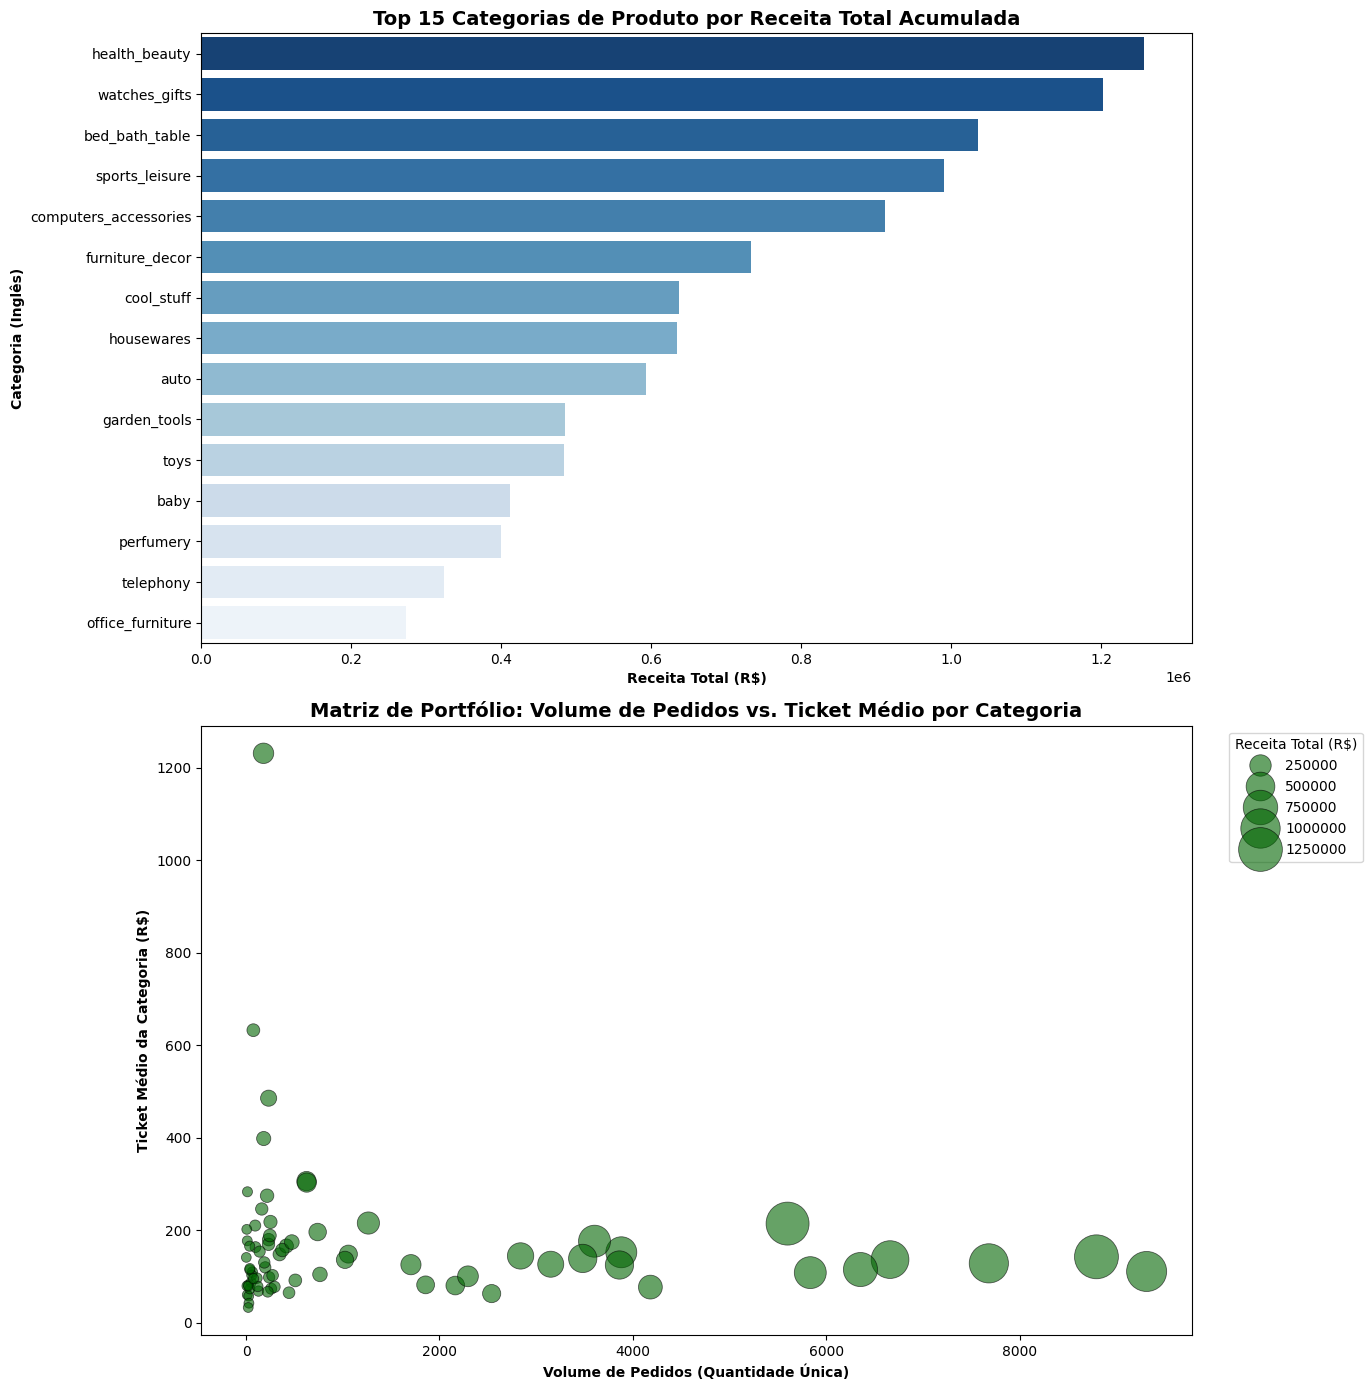

💰 TOP 5 CATEGORIAS EM FATURAMENTO:
product_category_name_english  receita_total  ticket_medio
                health_beauty     1257573.84        142.97
                watches_gifts     1202414.05        214.68
               bed_bath_table     1036209.66        111.24
               sports_leisure      989672.18        128.81
        computers_accessories      912110.31        136.93

💎 TOP 5 CATEGORIAS EM TICKET MÉDIO (Mínimo de 50 pedidos para evitar ruído):
        product_category_name_english  volume_pedidos  ticket_medio
                            computers             180       1230.96
small_appliances_home_oven_and_coffee              75        632.61
                    home_appliances_2             233        485.70
           agro_industry_and_commerce             182        398.52
                  musical_instruments             625        306.55


In [29]:
# ── PERGUNTA 5: Análise de Receita e Ticket Médio por Categoria ────────────

# 1. Agrupando os dados por categoria de produto
cat_analysis = df_master.groupby('product_category_name_english').agg(
    volume_pedidos=('order_id', 'nunique'),        # Quantidade de pedidos únicos na categoria
    qtd_itens_vendidos=('qtd_itens', 'sum'),       # Total de itens físicos vendidos
    receita_total=('valor_total_produtos', 'sum')  # Faturamento bruto da categoria
).reset_index()

# 2. Calculando o Ticket Médio por Categoria (Receita / Volume de Pedidos)
cat_analysis['ticket_medio'] = cat_analysis['receita_total'] / cat_analysis['volume_pedidos']

# 3. Separando as Top 15 Categorias por Receita para o primeiro gráfico
top15_receita = cat_analysis.sort_values(by='receita_total', ascending=False).head(15)

# 4. Criando a estrutura de gráficos (Subplots: um em cima do outro)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 14))

# GRAFICO 1: Top 15 Categorias por Receita (Barras Horizontais)
# 
sns.barplot(
    data=top15_receita,
    x='receita_total',
    y='product_category_name_english',
    palette='Blues_r',
    ax=ax1
)
ax1.set_title('Top 15 Categorias de Produto por Receita Total Acumulada', fontsize=14, fontweight='bold')
ax1.set_xlabel('Receita Total (R$)', fontweight='bold')
ax1.set_ylabel('Categoria (Inglês)', fontweight='bold')

# GRAFICO 2: Scatter Plot de Volume vs Ticket Médio (Tamanho do Ponto = Receita)
# 
sns.scatterplot(
    data=cat_analysis,
    x='volume_pedidos',
    y='ticket_medio',
    size='receita_total',
    sizes=(50, 1000), # Dá contraste visual para o tamanho das bolhas
    alpha=0.6,
    color='darkgreen',
    edgecolor='black',
    ax=ax2
)

ax2.set_title('Matriz de Portfólio: Volume de Pedidos vs. Ticket Médio por Categoria', fontsize=14, fontweight='bold')
ax2.set_xlabel('Volume de Pedidos (Quantidade Única)', fontweight='bold')
ax2.set_ylabel('Ticket Médio da Categoria (R$)', fontweight='bold')
ax2.legend(loc='upper right', title='Receita Total (R$)', bbox_to_anchor=(1.18, 1))

plt.tight_layout()
plt.show()

# ── 5. Extração de Destaques para Subsidiar o Insight ──────────────────────
print("💰 TOP 5 CATEGORIAS EM FATURAMENTO:")
print(cat_analysis.sort_values(by='receita_total', ascending=False).head(5)[['product_category_name_english', 'receita_total', 'ticket_medio']].round(2).to_string(index=False))

print("\n💎 TOP 5 CATEGORIAS EM TICKET MÉDIO (Mínimo de 50 pedidos para evitar ruído):")
cat_filtrada = cat_analysis[cat_analysis['volume_pedidos'] >= 50]
print(cat_filtrada.sort_values(by='ticket_medio', ascending=False).head(5)[['product_category_name_english', 'volume_pedidos', 'ticket_medio']].round(2).to_string(index=False))

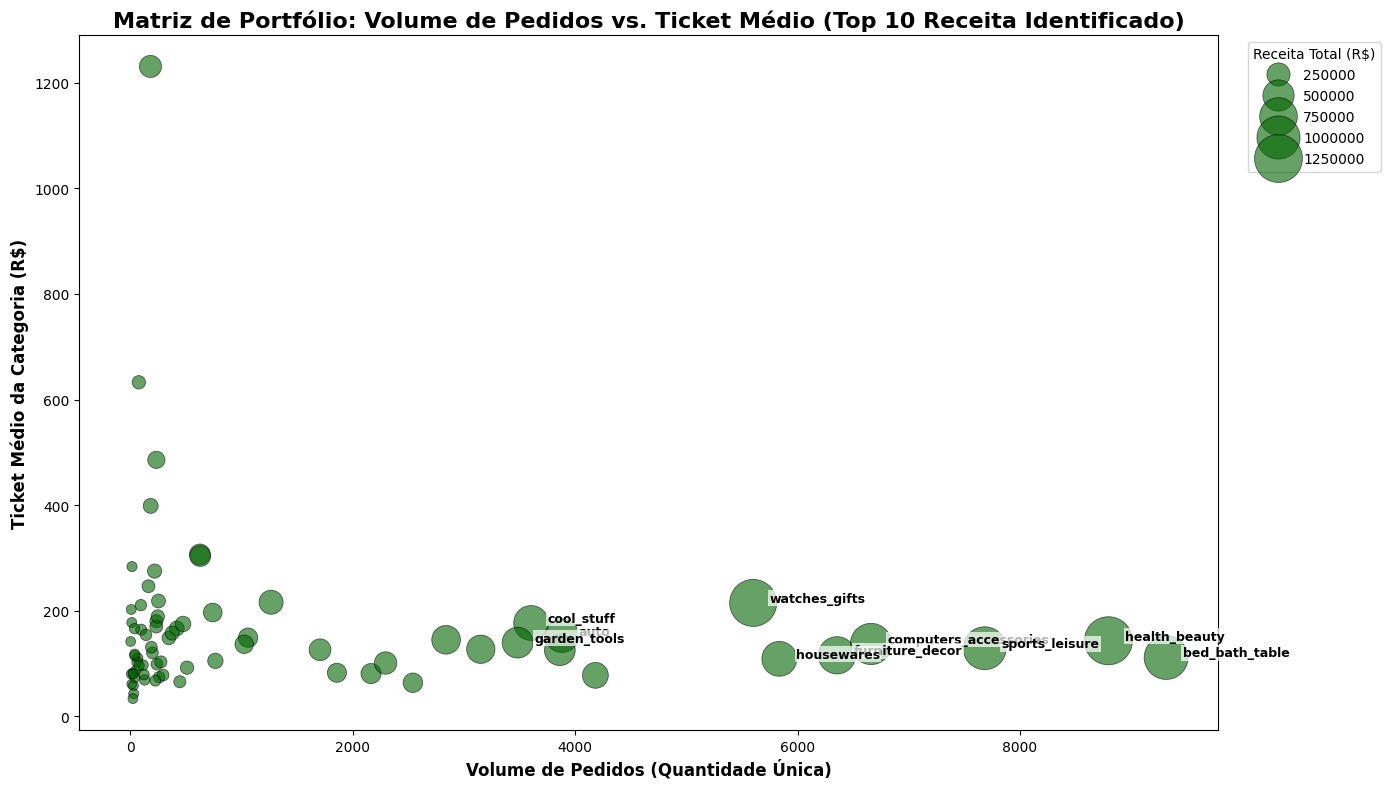

In [ ]:
# ── REFINAMENTO PERGUNTA 5: Scatter Plot Identificável (Top 10 Labels) ──────

# 1. Identificando as TOP 10 categorias por receita para aplicar os rótulos
top10_nomes_receita = cat_analysis.sort_values(by='receita_total', ascending=False).head(10)['product_category_name_english'].tolist()

fig, ax = plt.subplots(figsize=(14, 8))

# 2. Criando o Scatter Plot de Volume vs Ticket Médio
sns.scatterplot(
    data=cat_analysis,
    x='volume_pedidos',
    y='ticket_medio',
    size='receita_total',
    sizes=(50, 1200), 
    alpha=0.6,
    color='darkgreen',
    edgecolor='black',
    ax=ax
)

# 3. 🏷️ Adicionando os Labels de Texto dinamicamente (Apenas no Top 10 Receita)
for index, row in cat_analysis.iterrows():
    if row['product_category_name_english'] in top10_nomes_receita:
        ax.text(
            x = row['volume_pedidos'] + 150, 
            y = row['ticket_medio'] + 2, 
            s = row['product_category_name_english'],
            fontsize = 9,
            fontweight = 'bold',
            color = 'black',
            bbox = dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1) 
        )

# Customizações Estéticas Executivas
ax.set_title('Matriz de Portfólio: Volume de Pedidos vs. Ticket Médio (Top 10 Receita Identificado)', fontsize=16, fontweight='bold')
ax.set_xlabel('Volume de Pedidos (Quantidade Única)', fontsize=12, fontweight='bold')
ax.set_ylabel('Ticket Médio da Categoria (R$)', fontsize=12, fontweight='bold')

# Organizando e posicionando a legenda fora do gráfico para não cobrir os dados
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), title="Receita Total (R$)")

plt.tight_layout()
plt.show()

### 💡 Insight: Análise de Portfólio e Dinâmica de Ticket Médio

A análise cruzada entre Volume de Pedidos, Ticket Médio e Receita Total revela que o portfólio da Olist possui três perfis de produtos altamente definidos e complementares, desmistificando a ideia de que o faturamento depende de uma única categoria:

1. **Os Motores de Volume (Alto Volume / Ticket Médio Baixo-Médio):** Categorias como `bed_bath_table` (cama, mesa e banho), `health_beauty` (beleza e saúde) e `computers_accessories` (acessórios de informática) apresentam os maiores volumes de pedidos da plataforma. Operando com tickets moderados (entre R$ 90 e R$ 136), a alta recorrência e a escala massiva de vendas fazem delas pilares essenciais para manter o ecossistema ativo e atrair tráfego para o marketplace.

2. **As Joias da Coroa (Volume Relevante / Alto Ticket):** Categorias como `watches_gifts` (relógios e presentes) são o "cenário ideal" do negócio. Elas conseguem conciliar um volume de tração expressivo com um ticket médio elevado (frequentemente acima de R$ 200), sendo grandes responsáveis pelas margens de lucro agregadas.

3. **Nichos Premium de Alto Valor (Baixo Volume / Altíssimo Ticket):** No topo esquerdo do gráfico, observam-se categorias isoladas, com destaque absoluto para `computers` (computadores, com ticket médio de R$ 1.230). Elas registram uma quantidade muito menor de pedidos, mas o valor bruto altíssimo de cada transação mexe o ponteiro do faturamento individualmente.

**Conclusão Estratégica:** A diversificação do portfólio é saudável. A Olist não sofre de "dependência de produto único". A estratégia comercial deve focar em manter as categorias de volume como iscas de aquisição de clientes, enquanto cria campanhas de Cross-Selling para direcionar esses usuários para as categorias de alto ticket (Joias da Coroa e Nichos Premium).

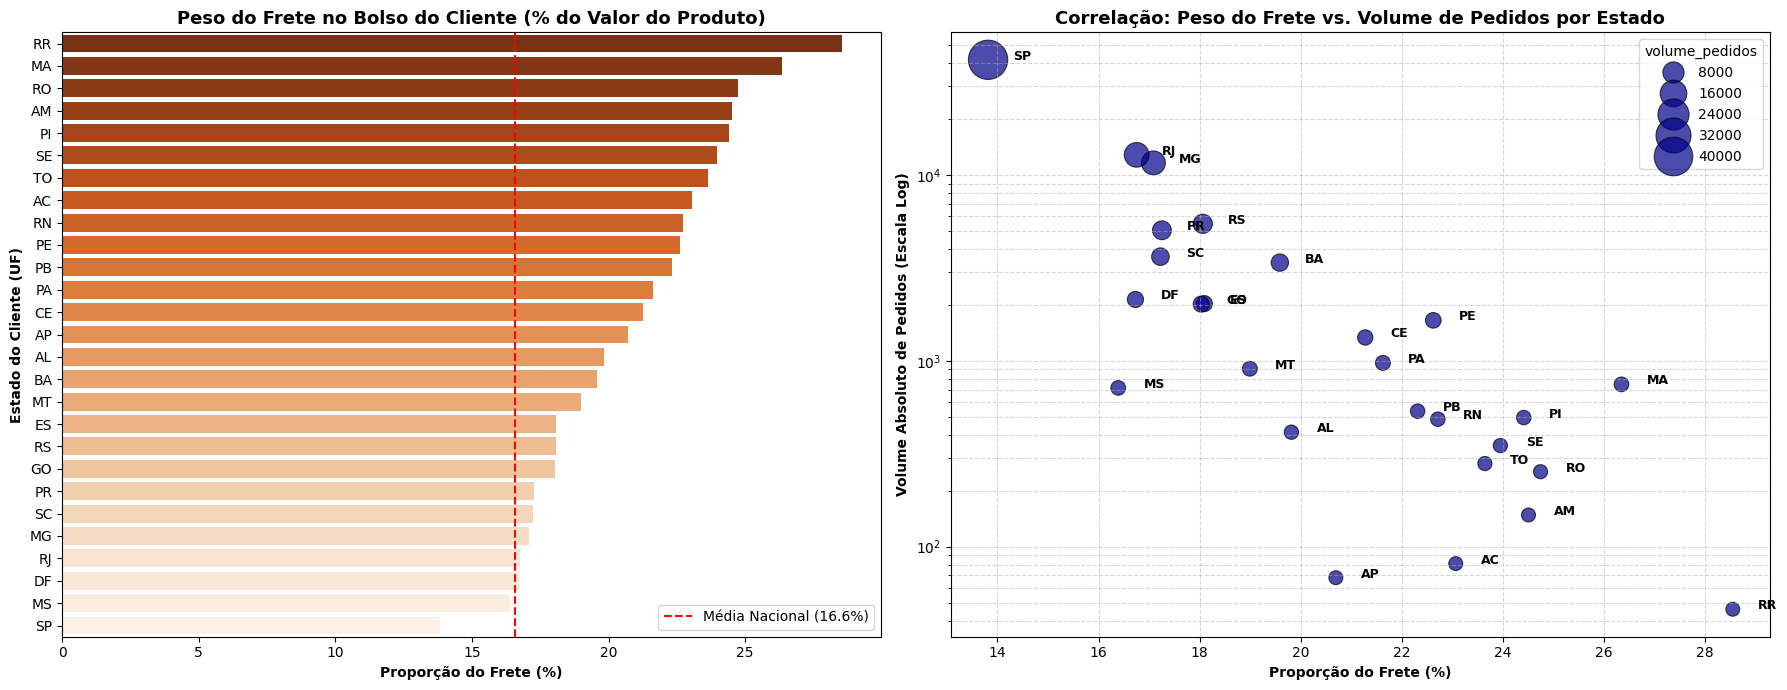

🚚 OS 5 ESTADOS COM FRETE MAIS DESPROPORCIONAL (MAIOR PESO):
customer_state  peso_frete_pct  volume_pedidos
            RR            28.5              46
            MA            26.3             747
            RO            24.7             253
            AM            24.5             148
            PI            24.4             495

📦 OS 5 ESTADOS COM FRETE MAIS BARATO (MENOR PESO):
customer_state  peso_frete_pct  volume_pedidos
            MG            17.1           11635
            RJ            16.8           12852
            DF            16.7            2140
            MS            16.4             715
            SP            13.8           41746


In [31]:
# ── PERGUNTA 6: Desproporção de Frete e Impacto no Volume por Estado ──────
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Agrupando os dados por Estado do Cliente
analise_estados = df_master.groupby('customer_state').agg(
    volume_pedidos=('order_id', 'nunique'),
    total_produtos=('valor_total_produtos', 'sum'),
    total_frete=('valor_total_frete', 'sum')
).reset_index()

# 2. Calculando o Peso do Frete (% em relação ao valor do produto)
analise_estados['peso_frete_pct'] = (analise_estados['total_frete'] / analise_estados['total_produtos']) * 100

# Ordenando pelos estados que pagam o frete mais desproporcional
analise_estados = analise_estados.sort_values(by='peso_frete_pct', ascending=False)

# 3. Criando a estrutura de gráficos (Dois subplots horizontais)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# GRÁFICO 1: Onde o frete é mais desproporcional? (Barras)
sns.barplot(
    data=analise_estados,
    x='peso_frete_pct',
    y='customer_state',
    palette='Oranges_r',
    ax=ax1
)
media_nacional_frete = (df_master['valor_total_frete'].sum() / df_master['valor_total_produtos'].sum()) * 100
ax1.axvline(media_nacional_frete, color='red', linestyle='--', linewidth=1.5, label=f'Média Nacional ({media_nacional_frete:.1f}%)')
ax1.set_title('Peso do Frete no Bolso do Cliente (% do Valor do Produto)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Proporção do Frete (%)', fontweight='bold')
ax1.set_ylabel('Estado do Cliente (UF)', fontweight='bold')
ax1.legend()

# GRÁFICO 2: Existe correlação entre frete alto e menos vendas? (Dispersão)
sns.scatterplot(
    data=analise_estados,
    x='peso_frete_pct',
    y='volume_pedidos',
    size='volume_pedidos',
    sizes=(100, 800),
    color='darkblue',
    alpha=0.7,
    edgecolor='black',
    ax=ax2
)

# Adicionando labels de texto nas bolhas para identificar os estados no Scatter
for index, row in analise_estados.iterrows():
    ax2.text(
        x=row['peso_frete_pct'] + 0.5,
        y=row['volume_pedidos'],
        s=row['customer_state'],
        fontsize=9,
        fontweight='bold'
    )

ax2.set_title('Correlação: Peso do Frete vs. Volume de Pedidos por Estado', fontsize=13, fontweight='bold')
ax2.set_xlabel('Proporção do Frete (%)', fontweight='bold')
ax2.set_ylabel('Volume Absoluto de Pedidos (Escala Log)', fontweight='bold')
ax2.set_yscale('log') # Escala logarítmica para permitir comparar SP com estados menores na mesma tela
ax2.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

# ── 4. Raio-X numérico para subsidiar o insight ───────────────────────────
print("🚚 OS 5 ESTADOS COM FRETE MAIS DESPROPORCIONAL (MAIOR PESO):")
print(analise_estados.head(5)[['customer_state', 'peso_frete_pct', 'volume_pedidos']].round(1).to_string(index=False))

print("\n📦 OS 5 ESTADOS COM FRETE MAIS BARATO (MENOR PESO):")
print(analise_estados.tail(5)[['customer_state', 'peso_frete_pct', 'volume_pedidos']].round(1).to_string(index=False))

### 💡 Insight: Assimetria Logística Regional e Atrito de Consumo

A análise regional expõe a profunda disparidade logística enfrentada pelo e-commerce no Brasil. O peso do frete no bolso do consumidor varia drasticamente dependendo da sua localização geográfica:

* **Zonas de Atrito Máximo (Norte/Nordeste):** Em estados como **Roraima (RR - 28,5%)**, **Maranhão (MA - 26,3%)** e **Rondônia (RO - 24,7%)**, o valor pago pelo frete consome mais de um quarto do valor total do produto adquirido.

* **Zonas de Eficiência (Sudeste/Sul):** No outro extremo, **São Paulo (SP - 13,8%)**, **Mato Grosso do Sul (MS - 16,4%)** e **Rio de Janeiro (RJ - 16,8%)** desfrutam do menor peso logístico da série, operando abaixo ou muito próximos da média nacional.

**Ressalva Metodológica Crítica (Correlação vs. Causalidade):**
O gráfico de dispersão indica uma correlação negativa clara: estados com maior peso de frete registram volumes de pedidos drasticamente menores (como RR com apenas 46 pedidos vs. SP com mais de 41 mil). No entanto, **correlação não implica causalidade direta**. 

Os volumes reduzidos em estados das regiões Norte e Nordeste são fortemente influenciados por fatores demográficos e socioeconômicos estruturais — como menor densidade populacional, isolamento geográfico e menor renda per capita média. O custo desproporcional do frete atua como uma **barreira de atrito adicional**, encarecendo o produto final e desestimulando a conversão, mas não deve ser interpretado como o único causador do baixo volume de vendas.

**Direcionamento de Negócio:** Para mitigar essa fricção nas regiões mais distantes e capturar o potencial de consumo represado, a Olist deve avaliar parcerias de *cross-docking* regionalizado ou incentivar a entrada de novos *sellers* baseados fora do eixo Sul-Sudeste, aproximando o estoque do cliente final.

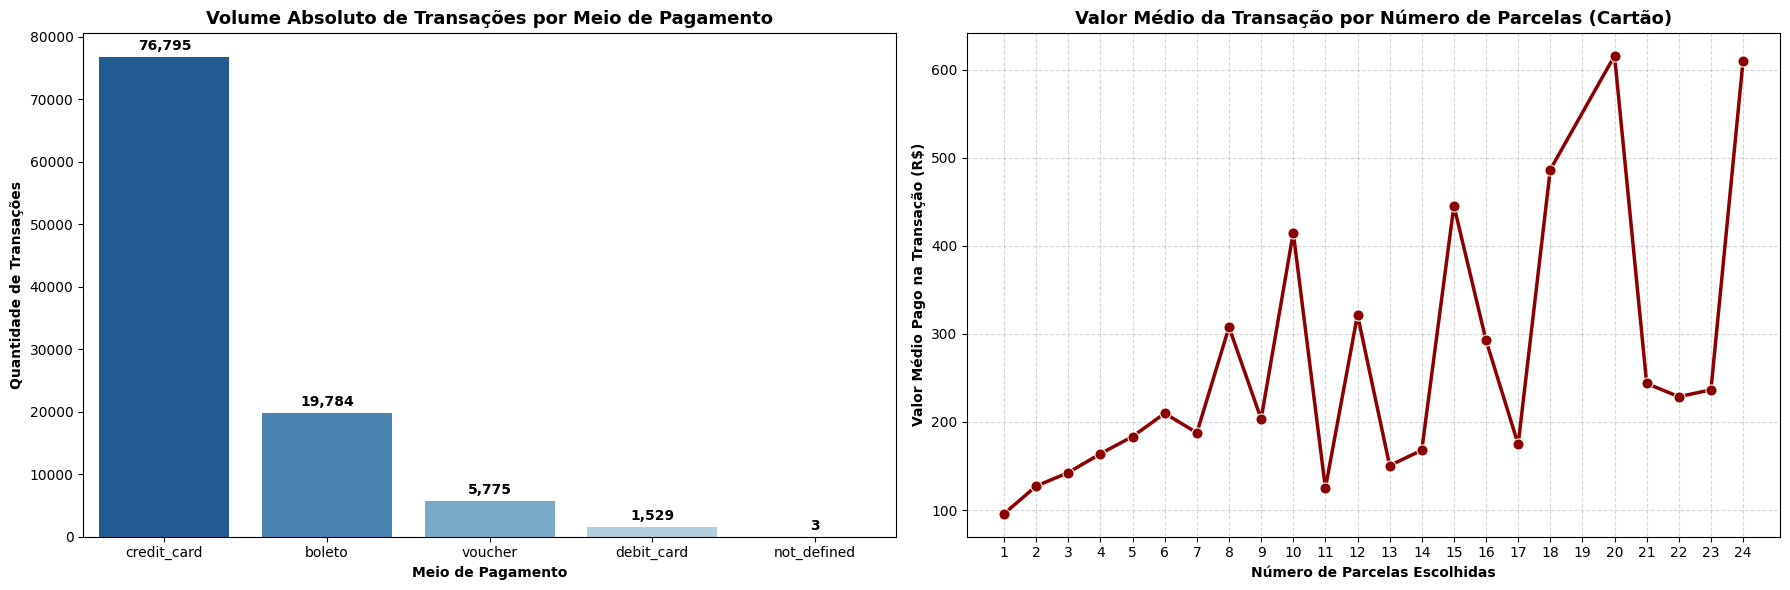

💳 PARTE 1: MATRIZ DE MEIOS DE PAGAMENTO (VOLUME ABSOLUTO):
forma_pagamento  volume_transacoes
    credit_card              76795
         boleto              19784
        voucher               5775
     debit_card               1529
    not_defined                  3

📈 PARTE 2: EVOLUÇÃO DO TICKET MÉDIO POR PARCELA (CARTÃO):
 payment_installments  payment_value
                    1          95.87
                    2         127.23
                    3         142.54
                    4         163.98
                    5         183.47
                    6         209.85
                    7         187.67
                    8         307.74
                    9         203.44
                   10         415.09
                   11         124.93
                   12         321.68
                   13         150.46
                   14         167.96
                   15         445.55
                   16         292.69
                   17         174.60
      

In [32]:
# ── PERGUNTA 7: Análise de Meios de Pagamento e Dinâmica de Parcelamento ──
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Carregando a tabela de pagamentos diretamente da fonte bruta
df_payments = pd.read_csv('../data/raw/olist_order_payments_dataset.csv')

# Criando a estrutura de gráficos: 1 linha com 2 subplots lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# ── PARTE 1: Distribuição por Forma de Pagamento (Volume de Transações) ──
payment_counts = df_payments['payment_type'].value_counts().reset_index()
payment_counts.columns = ['forma_pagamento', 'volume_transacoes']

sns.barplot(
    data=payment_counts,
    x='forma_pagamento',
    y='volume_transacoes',
    palette='Blues_r',
    ax=ax1
)

# Adicionando os rótulos com os números exatos no topo de cada barra
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height()):,}', 
                 (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha='center', va='baseline', fontsize=10, fontweight='bold', color='black',
                 xytext=(0, 5), textcoords='offset points')

ax1.set_title('Volume Absoluto de Transações por Meio de Pagamento', fontsize=13, fontweight='bold')
ax1.set_xlabel('Meio de Pagamento', fontweight='bold')
ax1.set_ylabel('Quantidade de Transações', fontweight='bold')


# ── PARTE 2: Parcelamento vs Valor do Pedido (Apenas Cartão de Crédito) ──
# Filtrando apenas cartão de crédito e removendo possíveis ruídos (parcelas < 1)
df_credit = df_payments[
    (df_payments['payment_type'] == 'credit_card') & 
    (df_payments['payment_installments'] >= 1)
].copy()

installments_analysis = df_credit.groupby('payment_installments')['payment_value'].mean().reset_index()

sns.lineplot(
    data=installments_analysis,
    x='payment_installments',
    y='payment_value',
    marker='o',
    markersize=8,
    linewidth=2.5,
    color='darkred',
    ax=ax2
)

ax2.set_title('Valor Médio da Transação por Número de Parcelas (Cartão)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Número de Parcelas Escolhidas', fontweight='bold')
ax2.set_ylabel('Valor Médio Pago na Transação (R$)', fontweight='bold')

max_parcelas = int(installments_analysis['payment_installments'].max())
ax2.set_xticks(range(1, max_parcelas + 1))
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# ── 2. Exibição dos dados analíticos estruturados no terminal ─────────────
print("💳 PARTE 1: MATRIZ DE MEIOS DE PAGAMENTO (VOLUME ABSOLUTO):")
print(payment_counts.to_string(index=False))

print("\n📈 PARTE 2: EVOLUÇÃO DO TICKET MÉDIO POR PARCELA (CARTÃO):")
print(installments_analysis.round(2).to_string(index=False))

📊 DISTRIBUIÇÃO COMPLETA (Antes do Filtro de Ruído):
 payment_installments  volume_transacoes  valor_medio
                    1              25455        95.87
                    2              12413       127.23
                    3              10461       142.54
                    4               7098       163.98
                    5               5239       183.47
                    6               3920       209.85
                    7               1626       187.67
                    8               4268       307.74
                    9                644       203.44
                   10               5328       415.09
                   11                 23       124.93
                   12                133       321.68
                   13                 16       150.46
                   14                 15       167.96
                   15                 74       445.55
                   16                  5       292.69
                   17         

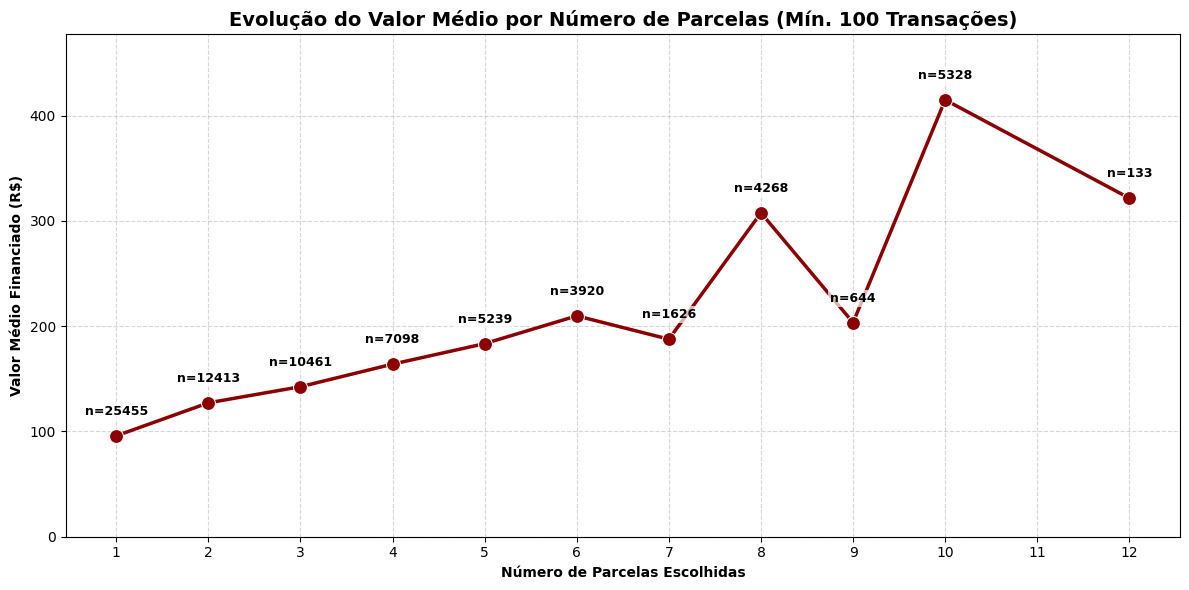

In [33]:
# ── REFINAMENTO PERGUNTA 7: Tratamento de Ruído no Parcelamento ───────────

# 1. Agrupando por parcelas: calculando o valor médio e o volume absoluto
installments_analysis = df_credit.groupby('payment_installments').agg(
    volume_transacoes=('payment_value', 'count'),
    valor_medio=('payment_value', 'mean')
).reset_index()

print("📊 DISTRIBUIÇÃO COMPLETA (Antes do Filtro de Ruído):")
print(installments_analysis.round(2).to_string(index=False))
print("-" * 50)

# 2. Aplicando a Regra de Corte: Mínimo de 100 transações estatisticamente válidas
installments_validas = installments_analysis[installments_analysis['volume_transacoes'] >= 100].copy()

# 3. Plotando o Gráfico de Linha Refinado e Anotado
fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=installments_validas,
    x='payment_installments',
    y='valor_medio',
    marker='o',
    markersize=10,
    linewidth=2.5,
    color='darkred',
    ax=ax
)

# Adicionando a quantidade de transações (n=X) como anotação em cada ponto
for index, row in installments_validas.iterrows():
    ax.annotate(
        f"n={int(row['volume_transacoes'])}",
        (row['payment_installments'], row['valor_medio']),
        textcoords="offset points",
        xytext=(0, 15), # Deslocamento vertical para não ficar em cima da bolinha
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='black',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1.5)
    )

# Customizações Visuais
ax.set_title('Evolução do Valor Médio por Número de Parcelas (Mín. 100 Transações)', fontsize=14, fontweight='bold')
ax.set_xlabel('Número de Parcelas Escolhidas', fontweight='bold')
ax.set_ylabel('Valor Médio Financiado (R$)', fontweight='bold')

# Ajustando o Eixo X para mostrar todas as parcelas sobreviventes ao filtro
max_parcelas_validas = int(installments_validas['payment_installments'].max())
ax.set_xticks(range(1, max_parcelas_validas + 1))
ax.grid(True, linestyle='--', alpha=0.5)

# Expandindo levemente o limite superior do Eixo Y para os labels não cortarem
ymax = installments_validas['valor_medio'].max()
ax.set_ylim(bottom=0, top=ymax * 1.15)

plt.tight_layout()
plt.show()

### 💡 Insight: Comportamento Financeiro e Dinâmica de Parcelamento

A análise detalhada da tabela de pagamentos revela os motores de conversão financeira da plataforma:

* **Domínio Absoluto do Cartão de Crédito:** Respondendo por 73% do volume total de transações, o cartão de crédito é a espinha dorsal do faturamento. Meios à vista (como boletos) ficam em um distante segundo lugar.

* **O Parcelamento como Alavanca de Ticket Médio:** Observa-se uma correlação positiva clara e linear do pagamento à vista (1x) até a 6ª parcela: quanto maior o valor do produto adquirido, maior é o número de parcelas escolhido pelo cliente para diluir o impacto financeiro. O parcelamento viabiliza a compra de itens mais caros.

* **O Fenômeno Cultural do "10x Sem Juros":** O gráfico apresenta uma quebra de linearidade com um pico expressivo exatamente na 10ª parcela, somando 5.328 transações e um ticket médio substancial de R$ 415. Isso não é uma anomalia estatística, mas sim o reflexo de campanhas promocionais ("em até 10x sem juros"), que atuam como âncoras psicológicas fundamentais no varejo brasileiro.

**Conclusão Estratégica:** A oferta de parcelamento estendido (especialmente o 10x) não é apenas um meio de cobrança, mas uma poderosa ferramenta de conversão e aumento de Ticket Médio. Limitar as opções de parcelamento fatalmente derrubaria as vendas das "Joias da Coroa" e dos "Nichos Premium" identificados na análise de portfólio.

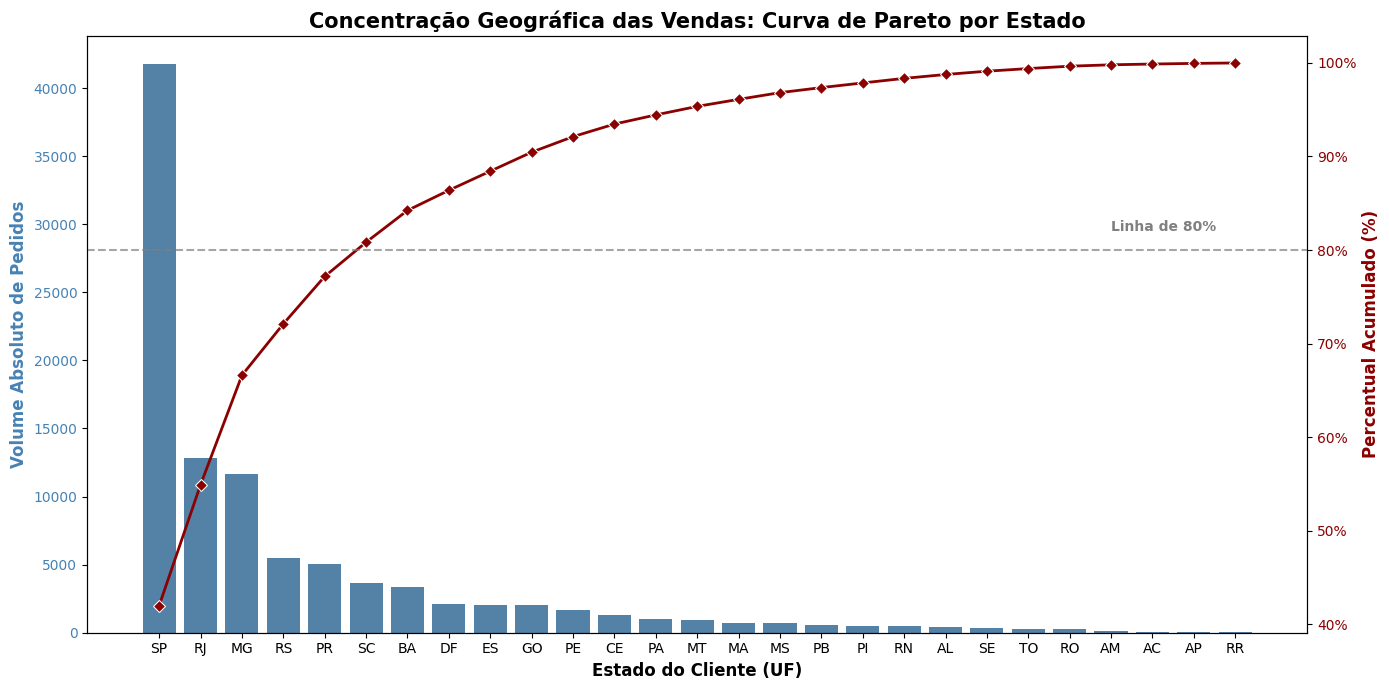

📍 TOP ESTADOS EM VOLUME DE VENDAS (PARETO):
estado  volume_pedidos  percentual  percentual_acumulado
    SP           41746       41.98                 41.98
    RJ           12852       12.92                 54.90
    MG           11635       11.70                 66.61
    RS            5466        5.50                 72.10
    PR            5045        5.07                 77.18
    SC            3637        3.66                 80.83
    BA            3380        3.40                 84.23
    DF            2140        2.15                 86.38
    ES            2033        2.04                 88.43
    GO            2020        2.03                 90.46


In [34]:
# ── PERGUNTA 8: Distribuição Geográfica das Vendas (Análise de Pareto) ──
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

# 1. Agrupando o volume de pedidos únicos por Estado (UF) do cliente
vendas_estado = df_master.groupby('customer_state')['order_id'].nunique().reset_index()
vendas_estado.columns = ['estado', 'volume_pedidos']

# 2. Ordenando do maior para o menor e calculando o Percentual Acumulado
vendas_estado = vendas_estado.sort_values(by='volume_pedidos', ascending=False)
vendas_estado['percentual'] = (vendas_estado['volume_pedidos'] / vendas_estado['volume_pedidos'].sum()) * 100
vendas_estado['percentual_acumulado'] = vendas_estado['percentual'].cumsum()

# 3. Criando o Gráfico de Pareto
fig, ax1 = plt.subplots(figsize=(14, 7))

sns.barplot(
    data=vendas_estado,
    x='estado',
    y='volume_pedidos',
    color='steelblue',
    ax=ax1
)
ax1.set_title('Concentração Geográfica das Vendas: Curva de Pareto por Estado', fontsize=15, fontweight='bold')
ax1.set_xlabel('Estado do Cliente (UF)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Volume Absoluto de Pedidos', fontsize=12, fontweight='bold', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
sns.lineplot(
    data=vendas_estado,
    x='estado',
    y='percentual_acumulado',
    color='darkred',
    marker='D',
    linewidth=2,
    ax=ax2
)
ax2.set_ylabel('Percentual Acumulado (%)', fontsize=12, fontweight='bold', color='darkred')
ax2.tick_params(axis='y', labelcolor='darkred')
ax2.yaxis.set_major_formatter(PercentFormatter())

ax2.axhline(80, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
ax2.text(len(vendas_estado)-4, 82, 'Linha de 80%', color='gray', fontweight='bold')

plt.tight_layout()
plt.show()

# ── 4. Exibição da Tabela Analítica no Terminal ───────────────────────────
print("📍 TOP ESTADOS EM VOLUME DE VENDAS (PARETO):")
print(vendas_estado.head(10).round(2).to_string(index=False))

### 💡 Insight: Concentração Geográfica e a "Tríade da Fricção" (Volume, Frete e Prazo)

A aplicação da Curva de Pareto revela uma dependência extrema da plataforma em relação à região Sudeste e a uma fração da região Sul. No entanto, o verdadeiro valor desta análise emerge quando cruzamos esta distribuição geográfica com os aprendizados logísticos anteriores (Perguntas 1 e 6):

* **O Ciclo Virtuoso do Sudeste:** Estados como SP, RJ e MG concentram a esmagadora maioria das vendas não apenas por questões demográficas e de renda, mas porque desfrutam de um ecossistema logístico altamente eficiente. Eles possuem as **menores taxas de atraso** (alta previsibilidade) e o **menor peso relativo de frete** (baixo atrito financeiro). A logística funciona, e o cliente recompra.

* **O Ciclo Vicioso do Norte/Nordeste:** Na base da cauda longa (estados como RR, AP e AM), o cenário se inverte drasticamente. Essas regiões sofrem de uma "fricção dupla": pagam **fretes desproporcionais** (chegando a quase 30% do valor do produto) e sofrem com as **maiores taxas de atraso** da plataforma. O cliente paga mais caro para, no fim, receber o pedido fora do prazo.

**Conclusão Estratégica (Fechamento da Fase de Exploração):** A Olist opera quase como duas empresas diferentes dependendo do CEP do cliente. No Sudeste, entrega uma experiência premium; nas margens do país, entrega uma experiência de alto custo e baixa confiabilidade. A expansão real de *Market Share* no Brasil exigirá romper esse modelo centralizado em São Paulo, adotando estoques avançados (Cross-docking regional) para replicar a eficiência do Sudeste no Norte e Nordeste.